In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate synthetic data

random.seed(121)

# samples
n = 100

# X matrix
X = np.random.rand(n, 1) * 10

# weight and bias
a = 2
b = 5

# noise
eps = np.random.randn(100) * 0.5

y = a * X[:, 0] + b + eps

print(X)
print(y)
print(X.shape)
print(y.shape)

# plt.scatter(X, y)
# plt.show()

[[5.18216151]
 [0.82459702]
 [7.48649201]
 [7.58517547]
 [2.03557091]
 [0.47883626]
 [6.69755201]
 [6.24066321]
 [3.37790037]
 [2.01755316]
 [4.03186162]
 [1.91861811]
 [4.10035389]
 [6.20444345]
 [7.87011378]
 [8.4681393 ]
 [1.57491234]
 [6.65338241]
 [1.59096521]
 [6.17130308]
 [4.39634674]
 [4.7235864 ]
 [8.66888965]
 [4.44141857]
 [7.13608129]
 [0.95642971]
 [4.62400402]
 [7.79232917]
 [8.3694325 ]
 [1.89893188]
 [4.86644288]
 [7.12553071]
 [3.82757623]
 [2.03934092]
 [9.25553503]
 [0.15005668]
 [7.14402613]
 [7.171637  ]
 [8.7250176 ]
 [1.81671091]
 [5.47381494]
 [9.72958236]
 [0.15694174]
 [2.45578084]
 [4.57636191]
 [0.85700753]
 [2.12183728]
 [0.73816916]
 [8.98503414]
 [6.6716438 ]
 [1.24970965]
 [4.26359183]
 [0.69630658]
 [7.28470683]
 [7.45121526]
 [9.07229763]
 [1.47080817]
 [6.72148255]
 [1.54180344]
 [4.31407657]
 [3.30203941]
 [3.25012151]
 [9.84781379]
 [0.70465142]
 [8.95535183]
 [4.4132662 ]
 [7.09749456]
 [4.9972057 ]
 [4.68121427]
 [8.60556104]
 [0.77198937]
 [4.45

(100, 2)
[[1.         5.18216151]
 [1.         0.82459702]
 [1.         7.48649201]
 [1.         7.58517547]
 [1.         2.03557091]
 [1.         0.47883626]
 [1.         6.69755201]
 [1.         6.24066321]
 [1.         3.37790037]
 [1.         2.01755316]
 [1.         4.03186162]
 [1.         1.91861811]
 [1.         4.10035389]
 [1.         6.20444345]
 [1.         7.87011378]
 [1.         8.4681393 ]
 [1.         1.57491234]
 [1.         6.65338241]
 [1.         1.59096521]
 [1.         6.17130308]
 [1.         4.39634674]
 [1.         4.7235864 ]
 [1.         8.66888965]
 [1.         4.44141857]
 [1.         7.13608129]
 [1.         0.95642971]
 [1.         4.62400402]
 [1.         7.79232917]
 [1.         8.3694325 ]
 [1.         1.89893188]
 [1.         4.86644288]
 [1.         7.12553071]
 [1.         3.82757623]
 [1.         2.03934092]
 [1.         9.25553503]
 [1.         0.15005668]
 [1.         7.14402613]
 [1.         7.171637  ]
 [1.         8.7250176 ]
 [1.         1.8

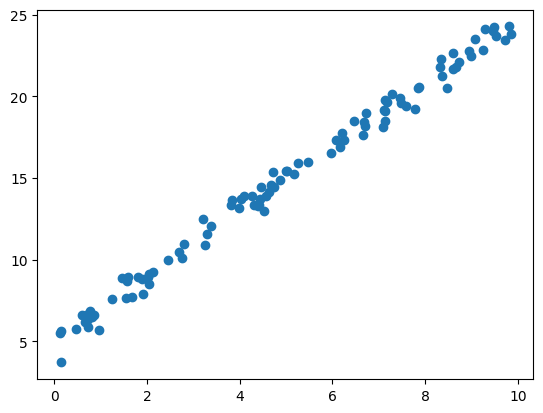

In [25]:
# 2. Prepare data - including bias in matrix of features

X_tilde = np.hstack([np.ones((n, 1)), X])

print(X_tilde.shape)
print(X_tilde)

plt.scatter(X, y)

In [26]:
# 3. Initialize parameters

w = np.zeros(X_tilde.shape[1])
print(w)
print(w.shape)


[0. 0.]
(2,)


In [5]:
# 4. Compute gradient descent

def predict(X, w):
    return X @ w

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def gradient(X, y, w):
    y_pred = predict(X, w)
    grad = (2 / len(y)) * (X.T @ (y_pred - y))
    return grad

In [6]:
# 5. Training loop

def gradient_descent(X, y, alpha=0.01, num_epochs=1000):
    w = np.zeros(X.shape[1])
    loss_history = []
    weight_history = []

    for epoch in range(num_epochs):
        y_pred = predict(X, w)
        loss = mse_loss(y, y_pred)
        grad = gradient(X, y, w)

        loss_history.append(loss)
        w = w - alpha * grad
        weight_history.append(w)

    return w, loss_history, np.array(weight_history)

w_final = gradient_descent(X_tilde, y)

[5.04550322 1.97569812]


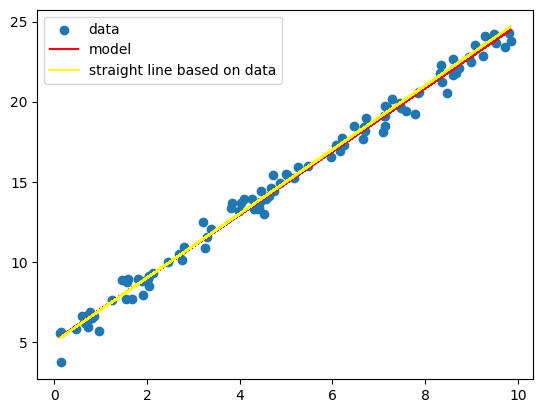

In [7]:
# 6. Checking results

print(w_final[0])

# results are satisfying - weight = 1.996 (while true weight was equal 2) and bias = 5.045 (while true bias was equal 5)

plt.scatter(X[:, 0], y, label = "data")
plt.plot(X[:, 0], predict(X_tilde, w_final[0]), label = "model", color = "red")
plt.plot(X[:, 0], a * X[:, 0] + b, label = "straight line based on data", color = "yellow")
plt.legend()


alpha: 1e-06
loss: 220.84684808240706
weights (final): [0.02863772 0.17310792]
alpha: 1e-05
loss: 70.35231680758149
weights (final): [0.22168461 1.30385341]
alpha: 0.0001
loss: 5.451411499790013
weights (final): [0.63796392 2.63922256]
alpha: 0.001
loss: 2.3440158856351747
weights (final): [2.27806764 2.39439165]
alpha: 0.01
loss: 0.29366646459743884
weights (final): [5.04550322 1.97569812]
alpha: 0.1
loss: nan
weights (final): [nan nan]


C:\Users\Wojtek\AppData\Local\Temp\ipykernel_6056\3251229376.py:7: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
C:\Users\Wojtek\AppData\Local\Temp\ipykernel_6056\3251229376.py:11: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(y)) * (X.T @ (y_pred - y))
C:\Users\Wojtek\AppData\Local\Temp\ipykernel_6056\2275746729.py:14: RuntimeWarning: invalid value encountered in subtract
  w = w - alpha * grad


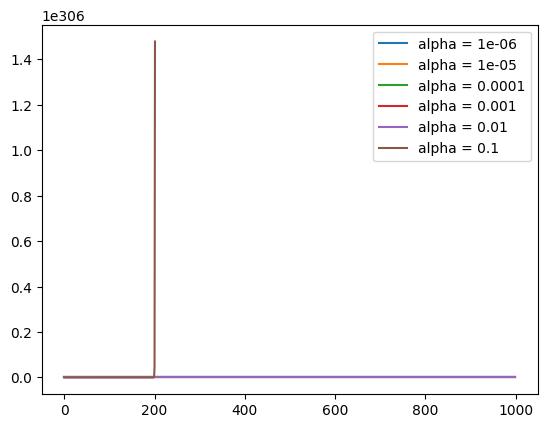

In [11]:
# 7. Experimenting with learning rate

alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
results = []

for alpha in alphas:
    w_final, loss_history, _ = gradient_descent(X_tilde, y, alpha = alpha)
    print("alpha:", alpha)
    print("loss:", loss_history[-1])
    print("weights (final):", w_final)
    plt.plot(loss_history, label = f"alpha = {alpha}")

plt.legend()

# we can see that alpha = 0.1 caused a huge instability


epoch: 50
weights (final): [1.46317127 2.51767974]
loss (final): 3.745965759464253
bias error: [1474.84249565 8947.32598558]
weight error: 0.5176797438819456

epoch: 100
weights (final): [2.28138517 2.39388974]
loss (final): 2.358174015356238
bias error: [1474.02428175 8946.50777168]
weight error: 0.39388973655187254

epoch: 250
weights (final): [3.78185185 2.16687968]
loss (final): 0.7350721007183069
bias error: [1472.52381507 8945.007305  ]
weight error: 0.1668796827594119

epoch: 500
weights (final): [4.7157677  2.02558478]
loss (final): 0.3272485314841683
bias error: [1471.58989922 8944.07338915]
weight error: 0.025584784054842213

epoch: 1000
weights (final): [5.04550322 1.97569812]
loss (final): 0.29366646459743884
bias error: [1471.2601637  8943.74365363]
weight error: 0.024301879945277216

epoch: 2000
weights (final): [5.07265515 1.97159022]
loss (final): 0.2934688183078032
bias error: [1471.23301176 8943.71650169]
weight error: 0.028409777118444612

epoch: 3000
weights (final)

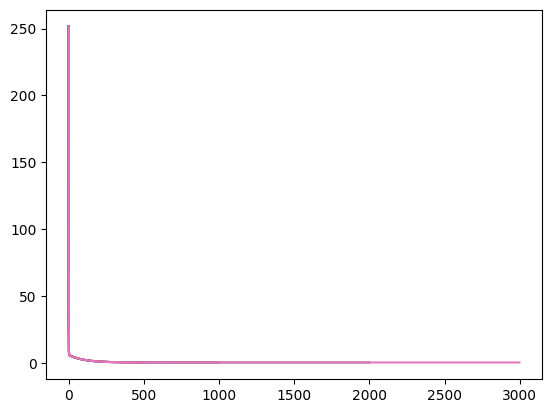

In [23]:
# 8. Experimenting with training duration

epochs = [50, 100, 250, 500, 1000, 2000, 3000]

for epoch in epochs:
    final_w, loss_history, _ = gradient_descent(X_tilde, y, num_epochs = epoch)
    print("epoch:", epoch)
    print("weights (final):", final_w)
    print("loss (final):", loss_history[-1])
    print("bias error:", abs(final_w[0] - b))
    print("weight error:", abs(final_w[1] - a))
    print("")

    plt.plot(loss_history, label = f"epoch = {epoch}")

# the improvement in model after 2000 epochs started being fractional

In [22]:
# 9. Visualize the loss landscape

b_vals = np.linspace(0, 10, 1000)
w_vals = np.linspace(0, 4, 1000)

B, W = np.meshgrid(b_vals, w_vals)
Z = np.zeros_like(B)

for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        w_tmp = np.array([B[i, j], W[i, j]])
        y_pred = predict(X_tilde, w_tmp)
        Z[i, j] = mse_loss(y, y_pred)

plt.contourf(B, W, Z, levels=30)
plt.colorbar(label="loss")

plt.scatter(0, 0, label="start")
plt.scatter(w_final[0], w_final[1], label="final")
plt.scatter(b, a, label="true")

plt.xlabel("bias")
plt.ylabel("weight")
plt.legend()
plt.title("Loss landscape")
plt.show()

KeyboardInterrupt: 

In [24]:
# 10. Analytical solution

A = X_tilde.T @ X_tilde
b = X_tilde.T @ y
A_inv = np.linalg.inv(A)

w_analytical = A_inv @ b

y_pred = X_tilde @ w_analytical
loss = np.mean((y_pred - y) ** 2)

print("analytical weights:", w_analytical)
print("analytical loss:", loss)

print("gradient descent weights:", final_w)
print("gradient descent loss:", loss_history[-1])



analytical weights: [5.07281496 1.97156605]
analytical loss: 0.2934688115407669
gradient descent weights: [5.07281403 1.97156619]
gradient descent loss: 0.2934688115409984
